# Metal-scrap material classification, end to end

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cubert-hyperspectral/cuvis-ai/blob/main/notebooks/use_cases/metal_scrap_classification.ipynb)

Hyperspectral classification of shredded steel scrap, reproducing **Gursch et al. (2026)**
("Hyperspectral scrap characterisation for scrap composition optimisation in steel recycling")
with the Cuvis.AI framework. Each SWIR pixel (437 bands, 948-1692 nm) is classified into one of
14 material classes from a 7x7 spatial-spectral patch. The paper trains an MLP, a 2D-CNN, and a
3D-CNN with a class-weighted cross-entropy loss; the 3D-CNN is best (76.5% pixel accuracy).

This notebook walks the whole workflow as a single pipeline, then adds a catalog cleanup stage:

```
  MetalScrapPatchDataModule (7x7 patches, 14 classes)
        |
        v
  PerChannelStandardizer  ->  SpectralSpatialCNN3D  -->  WeightedCrossEntropyLoss   (training)
   (per-band z-score)          (3D conv classifier)  \-> MulticlassSegmentationMetrics (eval)
  InverseFrequencyClassWeights  ----------------------->  (Phase-1 class weights into the loss)
        |
        v   inference: dense per-pixel prediction over a frame
  raw class map  --[ ClassMapRobustifier -> NearestLabelFill ]-->  cleaned map   (node-catalog extension)
```

What you get: build the pipeline, **train it** (on by default when a CUDA GPU is present, via
`RUN_TRAINING`) or load your own checkpoint, run **inference** on a held-out frame, and **clean up**
the prediction with a small morphology pipeline (`ClassMapRobustifier` -> `NearestLabelFill`) from
the Cuvis.AI node catalog.

> The classifier nodes live in the published `cuvis-ai-inspecscrap` plugin (GitHub, release v0.2.1)
> and the dataset is the InSpecScrap SWIR metal-scrap release (Zenodo, DOI 10.5281/zenodo.17076238).
> The dataset is downloaded from Zenodo and provisioned into a folder you point `DATASET_ROOT` at;
> the plugin is a git-tag manifest you `provision` once (or pip-install on Colab). The pre-trained
> weights are not published, so reproduce the figures by training on a GPU runtime.

In [ ]:
# Colab bootstrap -- no-op when running locally.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # The classifier family + data modules come from the published cuvis-ai-inspecscrap plugin
    # (git tag v0.2.1); the SWIR TIFF reader comes from cuvis-ai-dataloader[tiff].
    %pip install -q cuvis-ai "cuvis-ai-dataloader[tiff]" "cuvis-ai-inspecscrap @ git+https://github.com/cubert-hyperspectral/cuvis-ai-inspecscrap.git@v0.2.1"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: no GPU on this runtime. Training is disabled without a GPU (Runtime > "
            "Change runtime type > T4 GPU); inference then needs a local pre-trained checkpoint."
        )

## 1. Data and plugin setup

### Dataset
The HSIMetalScrap release (170 SWIR TIFF cubes + colourised class masks + `LabelMap.txt`) is
published on Zenodo (DOI 10.5281/zenodo.17076238). Download and unpack it, then point
`DATASET_ROOT` at the extracted folder (or reuse a local copy).

In [1]:
from pathlib import Path

# The HSIMetalScrap release is published on Zenodo (DOI 10.5281/zenodo.17076238). Download and
# unpack it, then point DATASET_ROOT at the extracted folder. On Colab, extract it under
# /content/data/HSIMetalScrap (or adjust the path below).
DATASET_ROOT = Path("/content/data/HSIMetalScrap") if IN_COLAB else Path("../../data/HSIMetalScrap")

DATA_AVAILABLE = DATASET_ROOT.exists()
if DATA_AVAILABLE:
    print("dataset:", DATASET_ROOT)
else:
    print(
        f"Dataset not found at {DATASET_ROOT}.\n"
        "Download the HSIMetalScrap release from Zenodo (DOI 10.5281/zenodo.17076238), extract it,\n"
        "and set DATASET_ROOT to the extracted folder. Training and inference below are skipped\n"
        "until it is present."
    )

dataset: D:\experiments\20260516\metal_scrapes\HSIMetalScrap


### Plugin

The classifier nodes (`SpectralSpatialCNN3D`, `PerChannelStandardizer`, `WeightedCrossEntropyLoss`,
`MulticlassSegmentationMetrics`, the data modules, ...) come from the published **cuvis-ai-inspecscrap**
plugin (GitHub, release v0.2.1), declared as a git-tag manifest at `configs/plugins/cuvis_ai_inspecscrap.yaml`.

Provision it into this environment **once** (then restart the kernel). The provisioner clones the
repo at its release tag and `uv pip install`s it; the TIFF reader the data module uses comes from
`cuvis-ai-dataloader[tiff]`.

In [2]:
# The classifier nodes come from the published cuvis-ai-inspecscrap plugin (git tag v0.2.1). Locally
# it is a manifest at configs/plugins/cuvis_ai_inspecscrap.yaml; provision it once (uncomment, run,
# then restart the kernel). On Colab it is pip-installed in the bootstrap cell above.
#   !uv run provision --plugins-dir configs/plugins --apply
#   !uv pip install "cuvis-ai-dataloader[tiff]"

# Register the plugin manifest for name-based pipeline resolution when the repo checkout is present
# (a no-op for this notebook, which imports the node classes directly below).
from cuvis_ai_core.utils.node_registry import NodeRegistry

_manifest = Path("../../configs/plugins/cuvis_ai_inspecscrap.yaml")
if _manifest.exists():
    NodeRegistry().register_plugin(str(_manifest))

2026-07-03 10:58:19.907 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'TiffDataNode' from 'cuvis_ai_inspecscrap.node.data.TiffDataNode'


2026-07-03 10:58:20.044 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'LegendStripNode' from 'cuvis_ai_inspecscrap.node.legend.LegendStripNode'


2026-07-03 10:58:20.045 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'RgbLabelToClassIndex' from 'cuvis_ai_inspecscrap.node.labels.RgbLabelToClassIndex'


2026-07-03 10:58:20.046 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'PerChannelStandardizer' from 'cuvis_ai_inspecscrap.node.normalization.PerChannelStandardizer'


2026-07-03 10:58:20.047 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'PatchSampler' from 'cuvis_ai_inspecscrap.node.patch_sampler.PatchSampler'


...

2026-07-03 10:58:22.853 | DEBUG    | cuvis_ai_core.utils.node_registry:_register_data_module:506 - Registered data module 'metal_scrap_patch' (MetalScrapPatchDataModule) from 'cuvis_ai_inspecscrap'


2026-07-03 10:58:22.853 | DEBUG    | cuvis_ai_core.utils.node_registry:_register_data_module:506 - Registered data module 'metal_scrap_dense_patch' (DensePatchDataModule) from 'cuvis_ai_inspecscrap'


2026-07-03 10:58:22.853 | DEBUG    | cuvis_ai_core.utils.node_registry:_register_data_module:506 - Registered data module 'metal_scrap_montage_columns' (MontageColumnDataModule) from 'cuvis_ai_inspecscrap'


2026-07-03 10:58:22.854 | INFO     | cuvis_ai_core.utils.node_registry:register_plugins_installed:534 - Loaded preinstalled plugin 'cuvis_ai_inspecscrap' with 18 nodes


2026-07-03 10:58:22.854 | INFO     | cuvis_ai_core.utils.node_registry:register_plugin:380 - Registered plugin 'cuvis_ai_inspecscrap' from ..\..\configs\plugins\cuvis_ai_inspecscrap.yaml


## 2. Imports

In [3]:
from __future__ import annotations

import numpy as np
import torch

# cuvis-ai-inspecscrap plugin (the classifier family + data modules + report sinks)
from cuvis_ai_inspecscrap.data import MetalScrapDataModule, MetalScrapPatchDataModule
from cuvis_ai_inspecscrap.data.dense_patch_datamodule import DensePatchDataModule
from cuvis_ai_inspecscrap.data.montage_column_datamodule import MontageColumnDataModule
from cuvis_ai_inspecscrap.node.class_map_accumulator import ClassMapAccumulator
from cuvis_ai_inspecscrap.node.classification.cnn3d import SpectralSpatialCNN3D
from cuvis_ai_inspecscrap.node.labels import PAPER_CLASSES, RgbLabelToClassIndex
from cuvis_ai_inspecscrap.node.losses import (
    InverseFrequencyClassWeights,
    WeightedCrossEntropyLoss,
)
from cuvis_ai_inspecscrap.node.metrics import MulticlassSegmentationMetrics
from cuvis_ai_inspecscrap.node.montage_sink import MontageColumnSink
from cuvis_ai_inspecscrap.node.normalization import PerChannelStandardizer
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.execution import Context
from IPython.display import Image
from PIL import Image as PILImage

# cuvis-ai node catalog (false-RGB selector, label colouriser + overlays, cleanup nodes) + framework
from cuvis_ai.node.channel_selector import RangeAverageFalseRGBSelector
from cuvis_ai.node.colormap import ClassMapToRGB
from cuvis_ai.node.compositing import LabelOverlay, TitleOverlay
from cuvis_ai.node.mask_ops import ClassMapRobustifier, NearestLabelFill
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import GradientTrainer, StatisticalTrainer
from cuvis_ai_core.training.config import OptimizerConfig, TrainerConfig
from cuvis_ai_core.training.predictor import Predictor

torch.manual_seed(42)
print("classes:", len(PAPER_CLASSES))

classes: 14


## 3. Configuration

In [4]:
# Run controls. Training needs a CUDA GPU, so RUN_TRAINING defaults on only when one is visible;
# set it explicitly to override. Inference runs only when weights are available (trained this run
# or loaded from PRETRAINED).
RUN_TRAINING = torch.cuda.is_available()
RUN_INFERENCE = True

ROOT = str(DATASET_ROOT)
LABELMAP = f"{ROOT}/LabelMap.txt"
PATCH = 7  # spatial patch size (paper protocol)
K = len(PAPER_CLASSES)
SEED = 42
EPOCHS = 20  # notebook-friendly; the paper trains a fixed 200 epochs
BATCH = 256  # paper batch size
CHUNK = 1024  # dense-inference chunk (keep modest; large 3D-conv batches are memory-heavy)

# Optional pre-trained 3D-CNN checkpoint. The weights are not published, so this is None by default:
# with a GPU the notebook trains from scratch. To skip training, point this at your own local
# checkpoint (a torch.save dict with a "state_dict" holding "standardizer"/"classifier").
PRETRAINED = None  # e.g. Path("path/to/metal_scrap_cnn3d_framework.pt")

# Local patch cache reused across training runs (relative to the notebook; gitignored).
CACHE_DIR = "output/.patch_cache"

# Graphviz renders of the pipeline DAG land here (gitignored).
RENDER_DIR = Path("output")
RENDER_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# Class colours for the 14 material classes, taken once from the dataset LabelMap.txt (the same
# name -> paper-class merge the label reader uses; classes absent from the LabelMap fall back to a
# distinct Tableau-20 colour). Keyed by class name; the montage colouriser below turns it into a
# per-id palette in PAPER_CLASSES order, so it feeds the catalog ClassMapToRGB(palette=...).
CLASS_COLORS: dict[str, tuple[int, int, int]] = {
    "steel": (234, 142, 45),
    "aluminium": (45, 255, 175),
    "copper": (120, 46, 46),
    "dark_rust_metal": (214, 44, 18),
    "light_rust_metal": (148, 103, 189),
    "painted_metal": (180, 12, 43),
    "can": (250, 50, 183),
    "stone": (98, 96, 235),
    "wood": (20, 233, 31),
    "painted_wood": (248, 191, 21),
    "plastic": (125, 25, 77),
    "rubber": (250, 250, 55),
    "styropor": (51, 221, 255),
    "fabric": (136, 110, 110),
}

## 4. Build the Cuvis.AI pipeline

Five nodes wired into one graph: a per-band standardizer feeds the 3D-CNN, whose logits drive both
the weighted-cross-entropy loss (training) and the multiclass-segmentation metrics (evaluation). A
class-weight estimator fits the inverse-frequency weights from the training labels in Phase 1 and
feeds them into the loss's `class_weights` port. This is the exact graph the framework trainer
optimises.

2026-07-03 10:58:23.535 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\Metal_Scrap_CNN3D.png


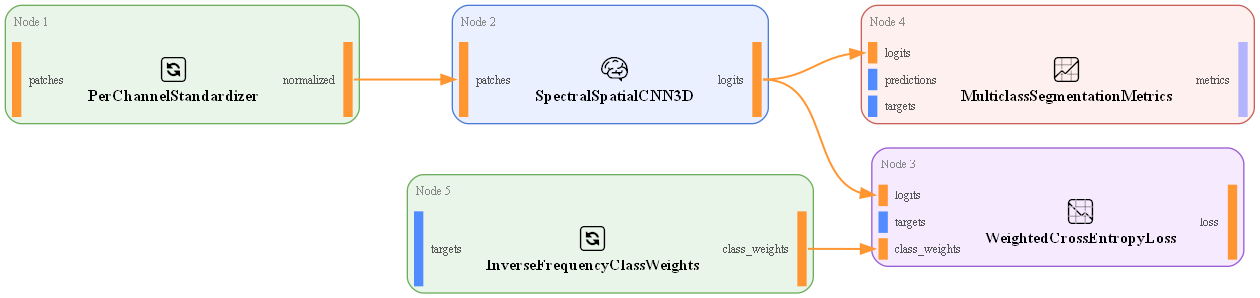

In [6]:
standardizer = PerChannelStandardizer(name="standardizer", in_channels=437)
classifier = SpectralSpatialCNN3D(
    name="classifier",
    in_channels=437,
    num_classes=K,
    conv3d_channels=(8, 16, 32),
    conv2d_channels=64,
    spectral_keep=4,
    hidden=(256, 128),
)
loss = WeightedCrossEntropyLoss(name="loss", num_classes=K)
# Class weights are a data-derived statistic: this entry node fits the inverse-frequency weights
# (paper Eq. 1) over the training labels in Phase 1 and feeds them into the loss's class_weights port.
weights = InverseFrequencyClassWeights(name="class_weights", num_classes=K)
metrics = MulticlassSegmentationMetrics(
    name="metrics", num_classes=K, class_names=list(PAPER_CLASSES)
)

pipeline = CuvisPipeline("Metal_Scrap_CNN3D")
pipeline.connect(
    (standardizer.outputs.normalized, classifier.inputs.patches),
    (classifier.outputs.logits, loss.inputs.logits),
    (classifier.outputs.logits, metrics.inputs.logits),
    (weights.outputs.class_weights, loss.inputs.class_weights),
)

# Render the graph with the pipeline's built-in Graphviz visualizer (category-coloured node
# cards with per-port dtype dots), the same helper the other use-case notebooks use.
graph_png = pipeline.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{pipeline.name}.png"),
)
display(Image(str(graph_png)))

## 5. Train the 3D-CNN (optional)

Training runs when a CUDA GPU is present (`RUN_TRAINING` defaults to `torch.cuda.is_available()`);
set it explicitly to override. It is a two-phase framework job. `StatisticalTrainer` first fits
every node that needs an initial pass: the per-band statistics and the inverse-frequency class
weights (the `class_weights` node accumulates the training-label distribution and feeds the loss, so
the paper's weighting is a fitted statistic, not a manual step). Then `GradientTrainer` (PyTorch
Lightning underneath) optimises the classifier with Adam and that class-weighted loss.

Training the 3D-CNN requires a CUDA GPU. If `RUN_TRAINING = True` and no GPU is visible, the cell
raises rather than falling back, so a training run never silently degrades to CPU. Set
`RUN_TRAINING = False` to skip training; inference then needs weights from a local checkpoint via
`PRETRAINED` (none are published).

> The committed figures come from a GPU training run. On a CUDA runtime `RUN_TRAINING` defaults on
> and reproduces them end to end; without a GPU, point `PRETRAINED` at a local checkpoint to run
> inference only.

In [7]:
model_available = False

if RUN_TRAINING and not DATA_AVAILABLE:
    print("RUN_TRAINING=True but the dataset is missing; skipping training (see the data cell).")
elif RUN_TRAINING:
    if not torch.cuda.is_available():
        raise RuntimeError(
            "RUN_TRAINING=True but no CUDA GPU is visible. Training the 3D-CNN requires a GPU; "
            "set RUN_TRAINING=False and point PRETRAINED at a checkpoint to run inference only."
        )
    print("Training the 3D-CNN through the framework trainers (GPU).")
    pipeline.to("cuda")
    dm = MetalScrapPatchDataModule(
        root=ROOT,
        batch_size=BATCH,
        patch_size=PATCH,
        seed=SEED,
        cache_dir=CACHE_DIR,
        train_samples=600,
        val_samples=400,
        eval_cap=5000,
        max_test_frames=6,
    )
    dm.setup(stage="fit")

    # Phase 1: statistical initialization. Fits both the per-band standardizer stats and the
    # inverse-frequency class weights (paper Eq. 1): the class_weights node accumulates the
    # training-label distribution and feeds the loss through its class_weights port, so the
    # weighting is a fitted statistic rather than a manual call.
    if any(n.requires_initial_fit for n in (standardizer, classifier, loss, metrics, weights)):
        StatisticalTrainer(pipeline=pipeline, datamodule=dm).fit()

    # Phase 2: gradient training of the classifier.
    pipeline.unfreeze_nodes_by_name(["classifier"])
    trainer = GradientTrainer(
        pipeline=pipeline,
        datamodule=dm,
        loss_nodes=[loss],
        metric_nodes=[metrics],
        trainer_config=TrainerConfig(
            max_epochs=EPOCHS,
            accelerator="gpu",
            devices=1,
            enable_checkpointing=False,
            enable_progress_bar=True,
            log_every_n_steps=10,
        ),
        optimizer_config=OptimizerConfig(name="adam", lr=1e-3),
    )
    trainer.fit()
    trainer.test(ckpt_path=None)
    md_metrics = metrics.epoch_metrics()
    print(
        f"test pixel acc {100 * md_metrics['pixel_accuracy']:.2f}% | "
        f"macro-P {100 * md_metrics['macro_precision']:.2f}% | "
        f"macro-R {100 * md_metrics['macro_recall']:.2f}% | "
        f"macro-F1 {100 * md_metrics['macro_f1']:.2f}%"
    )
    model_available = True
elif PRETRAINED is not None and Path(PRETRAINED).exists():
    print(f"Loading pre-trained 3D-CNN weights from {PRETRAINED} (training skipped).")
    state = torch.load(PRETRAINED, map_location="cpu", weights_only=False)["state_dict"]
    standardizer.load_state_dict(state["standardizer"])
    standardizer._statistically_initialized = True
    classifier.load_state_dict(state["classifier"])
    model_available = True
    print("pre-trained weights loaded.")
else:
    print(
        "No trained weights available. Set RUN_TRAINING=True on a GPU runtime to train the "
        "3D-CNN, or point PRETRAINED at a local checkpoint. Inference below is skipped."
    )

RUN_TRAINING=False -> loading the pre-trained 3D-CNN weights (training skipped).
pre-trained weights loaded.


## 6. Inference: a dense-inference pipeline driven by the Predictor

Inference is gated by `RUN_INFERENCE` (configuration cell) and runs on CPU: the dense pass is
deliberately kept off the GPU (one frame, memory-bounded chunks, reproducible without a CUDA
build). It does not depend on the training section, as long as weights are available (trained
this run, or loaded from a local `PRETRAINED` checkpoint).

Dense per-pixel prediction is a real `CuvisPipeline` run by the framework `Predictor`, not a
hand-rolled loop. A dense-patch DataModule tiles the frame into one 7x7 patch per labelled pixel,
**gathered lazily** so the DataLoader's `batch_size` IS the inference chunk and memory stays bounded
(a whole frame at once would blow up the 3D convolution). Every patch carries its provenance
`(frame_id, y, x)` and its centre-pixel target; one sink argmaxes the logits and scatters them into
a `[H, W]` class map, while a metrics sink scores pixel accuracy and macro-F1 over the same pass:

```
  DensePatchDataModule (batch_size = CHUNK, lazy patchify; each patch carries its centre target)
        |   Predictor.predict()
        v
  PerChannelStandardizer  ->  SpectralSpatialCNN3D  -->  ClassMapAccumulator (sink: [H, W] map)
   (per-band z-score)          (logits [N, 14])      \-> MulticlassSegmentationMetrics (acc + macro-F1)
```

Picking the most class-diverse held-out frame stays a small Python loop: it chooses a dataset index,
not a forward pass, so it is not a graph node.

The result is shown as a pipeline too, with no Python loop over the columns. A
`MontageColumnDataModule` serves one montage column per item (a caption + its class map over the
shared false-RGB), and the `Predictor` streams them through the same per-panel nodes; a
`MontageColumnSink` collects the captioned panels and, on `close()`, fans them into one side-by-side
image with a class legend (the side-by-side concat is a fan-in over the whole set, so it belongs in
the sink, exactly like `ClassMapAccumulator` rebuilds the dense map):

```
  MontageColumnDataModule (one column per item: caption + class map)
        |   Predictor.predict()
        v
  ClassMapToRGB -> LabelOverlay -> TitleOverlay -> MontageColumnSink (sink)
   (class id -> RGB)  (blend on false-RGB)  (caption per column)   (concat columns + class legend)
```

The false-RGB cube itself is rendered once by a `RangeAverageFalseRGBSelector` and handed to the
DataModule as every column's base image.

> On the full test set the 3D-CNN reproduces the paper at pixel level (73.6% on a whole-frame split;
> 62.9% under the paper's stricter leak-safe per-piece split), and the object-level majority vote
> lifts dense accuracy to 86.4%.

In [8]:
IGNORE = -100
mapper = RgbLabelToClassIndex(labelmap_path=LABELMAP)

# Visualization pipeline: a class-map colouriser feeds both the alpha overlay and the legend, the
# overlay is captioned per column, and the montage sink fans the captioned columns into one image.
false_rgb = RangeAverageFalseRGBSelector(
    name="false_rgb",
    red_range=(1400.0, 1550.0),
    green_range=(1200.0, 1350.0),
    blue_range=(1000.0, 1150.0),
)
# Catalog ClassMapToRGB takes an explicit per-id palette; build it from CLASS_COLORS in PAPER_CLASSES order.
colorizer = ClassMapToRGB(
    name="colorize",
    palette=[CLASS_COLORS[c] for c in PAPER_CLASSES],
    background_value=-1,
)
overlay = LabelOverlay(name="overlay", alpha=0.55, background_color=(0, 0, 0))
titler = TitleOverlay(name="title", font_size=18)
montage_sink = MontageColumnSink(
    name="montage", labelmap_path=LABELMAP, gap=8, bg_color=(1.0, 1.0, 1.0), legend_n_columns=7
)

render = CuvisPipeline("Metal_Scrap_Montage")
render.connect(
    (
        colorizer.outputs.label_rgb,
        overlay.inputs.label_rgb,
    ),  # class id -> RGB, blended on false-RGB
    (
        colorizer.outputs.label_rgb,
        montage_sink.inputs.label_rgb,
    ),  # same RGB drives the legend counts
    (overlay.outputs.frame, titler.inputs.frame),  # caption each blended panel
    (titler.outputs.frame, montage_sink.inputs.frame),  # collect + concat + legend in the sink
)


def render_montage(
    rgb_image: torch.Tensor, spec: list[tuple[str, np.ndarray | None]], png_name: str
) -> None:
    """Render the montage as a Predictor run over a column DataModule (no per-column Python loop).
    ``spec`` is ``[(caption, class_map | None), ...]``; ``None`` keeps the plain false-RGB (its
    all-background map colourises to black, which LabelOverlay leaves unblended). Each column is one
    DataModule item; the sink concatenates them and appends the legend on ``close()``."""
    base = rgb_image[0]  # [H, W, 3]; every column shares the same false-RGB base
    columns = [
        (caption, base, None if idmap is None else torch.from_numpy(idmap))
        for caption, idmap in spec
    ]
    dm = MontageColumnDataModule(columns=columns, background_value=-1)
    Predictor(pipeline=render, datamodule=dm).predict(collect_outputs=False)
    arr = (montage_sink.montage[0].clamp(0, 1) * 255).round().to(torch.uint8).cpu().numpy()
    out_png = RENDER_DIR / png_name
    PILImage.fromarray(arr).save(out_png)
    display(Image(str(out_png)))

C:\Users\nima.ghorbani\AppData\Local\Temp\ipykernel_49872\3511700487.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  tgt_i = mapper.forward(label_rgb=torch.from_numpy(scan_ds[i]["label_rgb"]).unsqueeze(0))[


Predict [Metal_Scrap_Dense_Inference]:   0%|          | 0/60 [00:00<?, ?batch/s]

DataSet0_09-47-33 (DataSet0) | 3D-CNN  acc 47.5%  macro-F1 44.0%


Predict [Metal_Scrap_Montage]:   0%|          | 0/1 [00:00<?, ?batch/s]

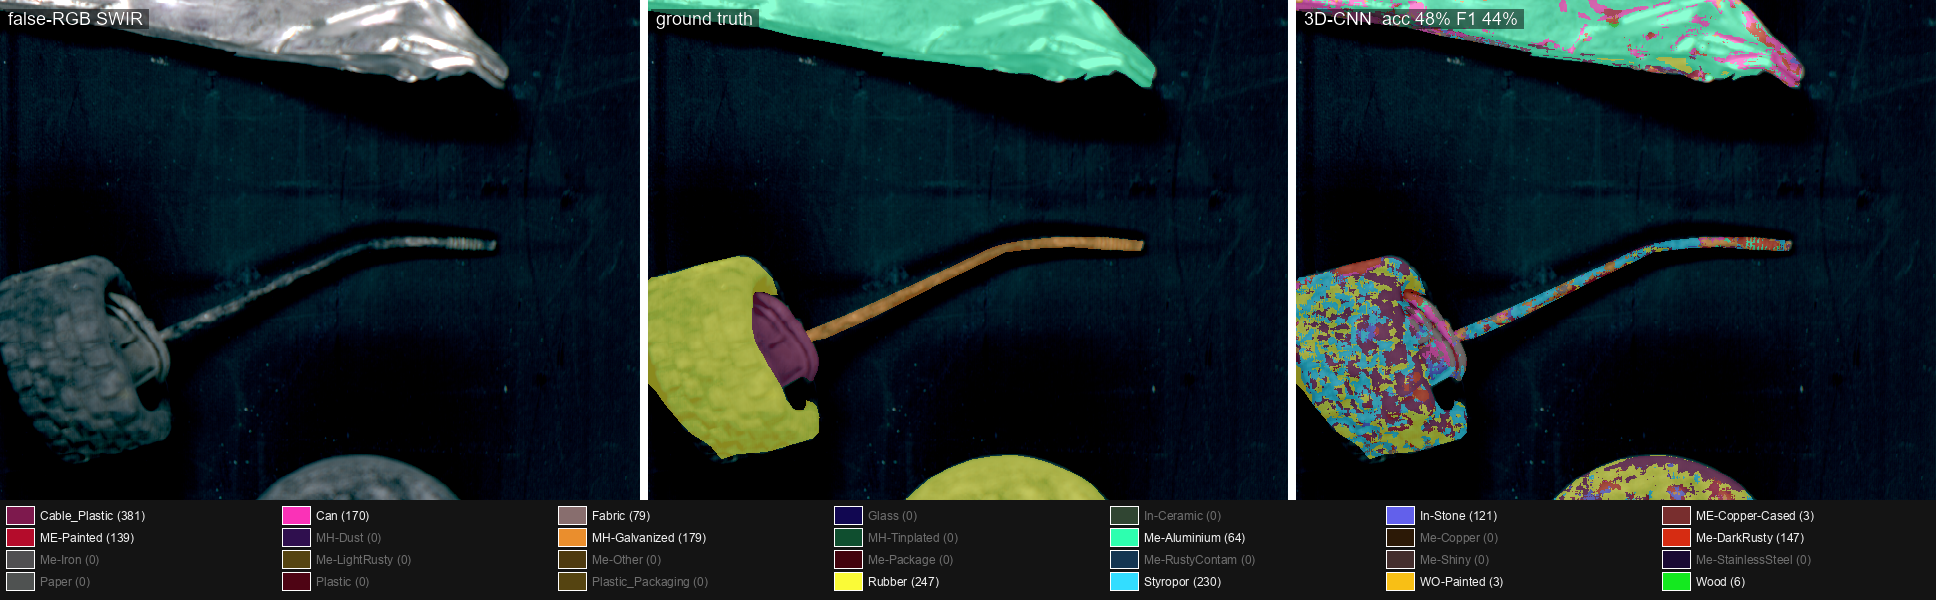

In [9]:
if RUN_INFERENCE and model_available:
    standardizer.eval().cpu()  # dense inference runs on CPU (see the section note)
    classifier.eval().cpu()
    # Frame selection is a dataset-index choice (not a forward pass), so it stays a Python loop:
    # pick the most class-diverse held-out test frame.
    SPLIT = {"split_mode": "random_frame", "test_fraction": 0.2, "val_fraction": 0.15, "seed": SEED}
    scan = MetalScrapDataModule(root=ROOT, read_cube=False, **SPLIT)
    scan_ds = scan.build_stage_dataset("test")
    diversity = []
    for i in range(len(scan_ds)):
        tgt_i = mapper.forward(label_rgb=torch.from_numpy(scan_ds[i]["label_rgb"]).unsqueeze(0))[
            "targets"
        ][0]
        diversity.append((int(torch.unique(tgt_i[tgt_i != IGNORE]).numel()), i))
    frame_idx = max(diversity)[1]

    # Ground truth + false-RGB for that same frame (same split params -> same partition).
    item = MetalScrapDataModule(root=ROOT, read_cube=True, **SPLIT).build_stage_dataset("test")[
        frame_idx
    ]
    cube = item["cube"]
    tgt = mapper.forward(label_rgb=torch.from_numpy(item["label_rgb"]).unsqueeze(0))["targets"][0]
    fg = tgt != IGNORE
    H, W = tgt.shape
    gt_map = np.full((H, W), -1, np.int64)
    gt_map[fg.numpy()] = tgt[fg].numpy()

    # Dense inference as a CuvisPipeline run by the Predictor (batch_size = CHUNK = the inference chunk).
    # A metrics sink scores the pass live: every dense patch carries its centre-pixel target, so pixel
    # accuracy and macro-F1 come straight from MulticlassSegmentationMetrics, not an inline comparison.
    accumulator = ClassMapAccumulator(name="class_map", background_value=-1)
    dense_metrics = MulticlassSegmentationMetrics(
        name="dense_metrics",
        num_classes=K,
        ignore_index=IGNORE,
        class_names=list(PAPER_CLASSES),
        execution_stages={ExecutionStage.INFERENCE},
    )
    infer = CuvisPipeline("Metal_Scrap_Dense_Inference")
    infer.connect(
        (standardizer.outputs.normalized, classifier.inputs.patches),
        (classifier.outputs.logits, accumulator.inputs.logits),  # argmax + scatter -> [H, W] map
        (classifier.outputs.logits, dense_metrics.inputs.logits),  # pixel accuracy + macro-F1 sink
    )
    dense_dm = DensePatchDataModule(
        root=ROOT,
        patch_size=PATCH,
        batch_size=CHUNK,
        frame_indices=[frame_idx],
        ignore_index=IGNORE,
        labelmap_path=LABELMAP,
        **SPLIT,
    )
    Predictor(pipeline=infer, datamodule=dense_dm).predict(collect_outputs=False)
    pred_map = accumulator.class_maps[0].numpy()  # [H, W]; one selected frame -> id 0
    md = dense_metrics.epoch_metrics()
    acc, f1 = md["pixel_accuracy"] * 100, md["macro_f1"] * 100

    cube_t = torch.from_numpy(np.ascontiguousarray(cube)).float().unsqueeze(0)
    rgb = false_rgb.forward(cube=cube_t, wavelengths=torch.as_tensor(item["wavelengths"]))[
        "rgb_image"
    ]

    print(f"{item['stem']} ({item['dataset']}) | 3D-CNN  acc {acc:.1f}%  macro-F1 {f1:.1f}%")
    render_montage(
        rgb,
        [
            ("false-RGB SWIR", None),
            ("ground truth", gt_map),
            (f"3D-CNN  acc {acc:.0f}% F1 {f1:.0f}%", pred_map),
        ],
        "metal_scrap_prediction.png",
    )
else:
    print("Skipping dense inference (needs RUN_INFERENCE=True and available weights).")

## 7. Extension: clean up the prediction with a morphology pipeline

The raw per-pixel prediction is spatially noisy: salt-and-pepper speckle inside otherwise solid
pieces. The cleanup is a second `CuvisPipeline` of two Cuvis.AI catalog nodes: `ClassMapRobustifier`
runs per-class morphological opening/closing plus small-component removal over the label map, and
`NearestLabelFill` repaints the gaps left by removed speckle from the nearest surviving label.
Run on the assembled frame with one `forward`, it turns the speckled map into solid regions, with
no retraining.

> On the full test set this cleanup lifts the 3D-CNN's pixel accuracy by roughly 4 points (about
> 79% -> 84%; see the reproduction report for exact figures) and raises both macro precision and
> recall. The strength is tuned to this scene (a 3x3 kernel, 60-pixel minimum blob); more aggressive
> settings would erode genuinely thin structures.

Predict [Metal_Scrap_Montage]:   0%|          | 0/1 [00:00<?, ?batch/s]

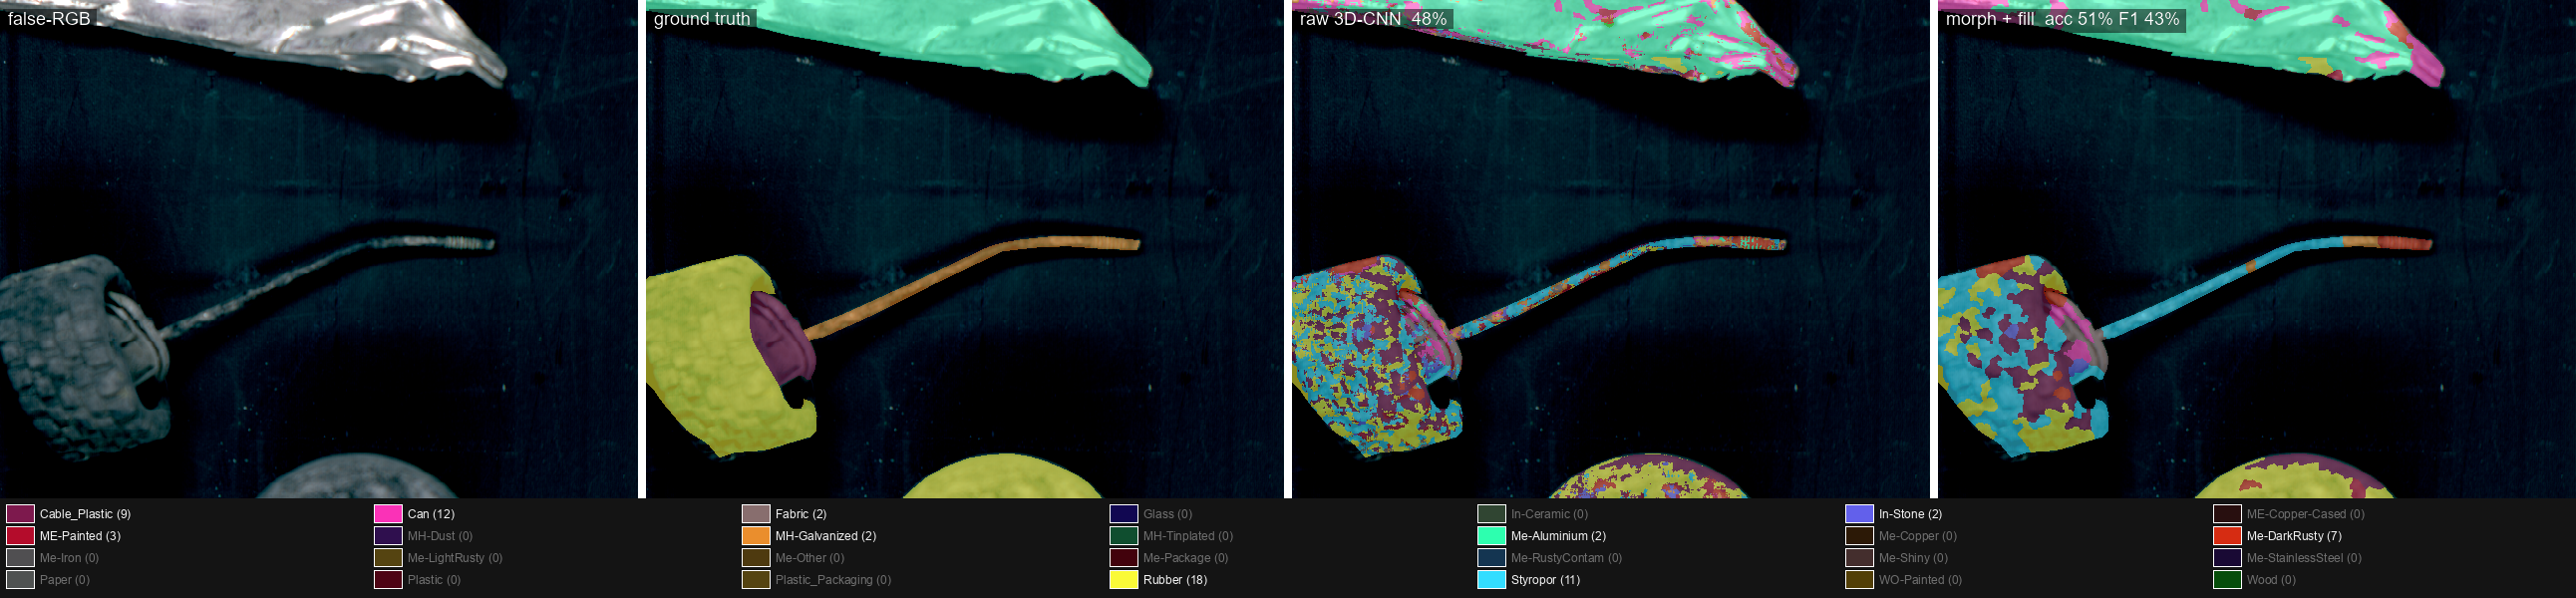

frame: raw acc 47.5% / F1 44.0%  ->  cleaned acc 50.9% / F1 43.4% (acc +3.3, F1 -0.6)


In [10]:
if RUN_INFERENCE and model_available:
    # Cleanup as a second CuvisPipeline of two catalog nodes: ClassMapRobustifier runs per-class
    # morphology over the label map (despeckle + close + min-area filter), then NearestLabelFill repaints
    # the gaps it left from the nearest surviving label. It runs on the assembled frame with a single
    # forward (one in-memory map, no streaming), replacing the hand-rolled per-class loop + EDT fill.
    robustifier = ClassMapRobustifier(
        name="robustifier",
        opening_kernel=3,
        closing_kernel=3,
        min_area=60,
        keep_largest=False,
        background_value=-1,
    )
    filler = NearestLabelFill(name="gap_fill", background_value=-1)
    cleanup = CuvisPipeline("Metal_Scrap_Cleanup")
    cleanup.connect(
        (
            robustifier.outputs.class_map,
            filler.inputs.class_map,
        ),  # cleaned map (speckle -> background)
        (robustifier.outputs.source, filler.inputs.source),  # original map: foreground + fallback
    )

    out = cleanup.forward(batch={"class_map": torch.from_numpy(pred_map).unsqueeze(0)})
    cleaned_map = out[(filler.name, "class_map")][0].numpy()

    # Score the cleaned frame with the same metrics node, post-hoc on the assembled map (the cleanup is a
    # single-frame op, so there is nothing to stream): feed the cleaned labels vs the ground truth.
    clean_metrics = MulticlassSegmentationMetrics(
        name="clean_metrics",
        num_classes=K,
        ignore_index=IGNORE,
        class_names=list(PAPER_CLASSES),
    )
    clean_metrics.forward(
        predictions=torch.from_numpy(cleaned_map).reshape(-1),
        targets=tgt.reshape(-1),
        context=Context(stage=ExecutionStage.INFERENCE, epoch=0, batch_idx=0),
    )
    mc = clean_metrics.epoch_metrics()
    acc_clean, f1_clean = mc["pixel_accuracy"] * 100, mc["macro_f1"] * 100

    # Same montage pipeline, now four captioned columns (reusing the false-RGB from the inference cell).
    render_montage(
        rgb,
        [
            ("false-RGB", None),
            ("ground truth", gt_map),
            (f"raw 3D-CNN  {acc:.0f}%", pred_map),
            (f"morph + fill  acc {acc_clean:.0f}% F1 {f1_clean:.0f}%", cleaned_map),
        ],
        "metal_scrap_cleanup.png",
    )
    print(
        f"frame: raw acc {acc:.1f}% / F1 {f1:.1f}%  ->  cleaned acc {acc_clean:.1f}% / F1 {f1_clean:.1f}% "
        f"(acc {acc_clean - acc:+.1f}, F1 {f1_clean - f1:+.1f})"
    )
else:
    print("Skipping cleanup (needs RUN_INFERENCE=True and available weights).")

## Conclusion

We built the Gursch et al. steel-scrap classifier as a single Cuvis.AI pipeline, trained it through
the framework trainers (or loaded the pre-trained 3D-CNN), then ran dense per-pixel inference as a
second `CuvisPipeline` driven by the `Predictor` (a lazy `DensePatchDataModule` whose batch size is
the inference chunk, feeding standardizer -> classifier -> a `ClassMapAccumulator` sink that rebuilds
the class map), and rendered the result as a third `Predictor`-driven pipeline (a
`MontageColumnDataModule` streaming one column per item through `ClassMapToRGB` -> `LabelOverlay` ->
`TitleOverlay` -> a `MontageColumnSink` that concatenates the captioned columns and appends the
legend), then cleaned the prediction with a fourth pipeline (the catalog's `ClassMapRobustifier` ->
`NearestLabelFill` nodes), all without a hand-rolled loop. The same training graph and data module are
what `restore-trainrun` drives from a trainrun YAML, and the full reproduction (frame vs leak-safe
object split, object-level vote, fidelity audit) is written up alongside the plugin.

The dataset (Zenodo, DOI 10.5281/zenodo.17076238) and the `cuvis-ai-inspecscrap` plugin (GitHub,
release v0.2.1) are both published; the data-download and provision cells above use them directly.